## imports

In [1]:
#
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore, pearsonr
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

## set paths

In [2]:
#
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## define some functions

In [4]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [5]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [6]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [7]:
def corr_pearsonr(rs1, rs2):
    return _z2r(np.array(pearsonr(_r2z(np.array(rs1)), _r2z(np.array(rs2)))))

# how do accuracies during various recall sessions affect subsequent ones?

In [8]:
#
a1a2_acc = []
a2_acc = []
a1arrdev_acc = []
arrdev_acc = []

dela2_acc = []
delarrdev_acc = []

preda2_acc = []
predarrdev_acc = []


# for each participant and their atlep1 recall events
for (turkid1, atl1_events) in participant_events['atlep1']:
    
    # get their immediate recall event/episode event mappings
    atl1_matches = next(ms for tid, ms in event_mappings['atlep1'] if tid == turkid1)
    
    # get their across-session ID
    sid, turkid2 = next((sid, id_maps[sid]['session 2']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 1'] == turkid1)
    
    # find average average accuracy for atlep1 event recall
    atl1_acc = corr_mean(np.diag((1-cdist(atl1_events, episode_events['atlep1'][atl1_matches], 'correlation'))))
    
    # also get their delayed recall events, mappings and accuracy
    del_events = next(sub_evs for tid, sub_evs in participant_events['delayed'] if tid == turkid2)
    del_matches = next(ms for tid, ms in event_mappings['delayed'] if tid == turkid2)
    del_acc = corr_mean(np.diag((1-cdist(del_events, episode_events['atlep1'][del_matches], 'correlation'))))
    
    # and get info for predictions
    pred_events = next(sub_evs for tid, sub_evs in participant_events['prediction'] if tid == turkid1)
    pred_matches = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    pred_acc = corr_mean(np.diag((1-cdist(pred_events, episode_events['atlep2'][pred_matches], 'correlation'))))
    
    
    # get their session 2 recall events, matches, and accuracy
    if 'A' in sid:
        # if they watched atlep2
        ses2_events = next(sub_evs for tid, sub_evs in participant_events['atlep2'] if tid == turkid2)
        ses2_matches = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
        ses2_acc = corr_mean(np.diag((1-cdist(ses2_events, episode_events['atlep2'][ses2_matches], 'correlation'))))
        
        a1a2_acc.append(atl1_acc)
        a2_acc.append(ses2_acc)
        dela2_acc.append(del_acc)
        preda2_acc.append(pred_acc)
        
        
     
    elif 'B' in sid:
        # or if they watched arrdev
        ses2_events = next(sub_evs for tid, sub_evs in participant_events['arrdev'] if tid == turkid2)
        ses2_matches = next(ms for tid, ms in event_mappings['arrdev'] if tid == turkid2)
        ses2_acc = corr_mean(np.diag((1-cdist(ses2_events, episode_events['arrdev'][ses2_matches], 'correlation'))))
        
        a1arrdev_acc.append(atl1_acc)
        arrdev_acc.append(ses2_acc)
        delarrdev_acc.append(del_acc)
        predarrdev_acc.append(pred_acc)
        
    

## is recall accuracy for atl1 related to session 2 recall acccuracy?

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


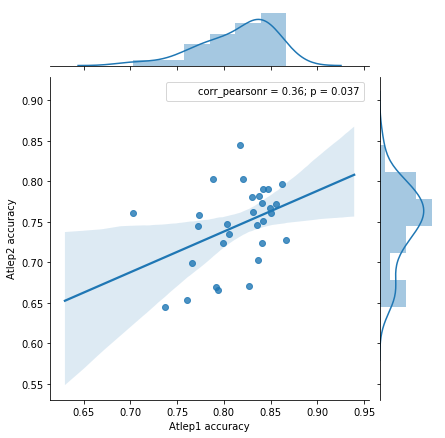

In [9]:
sns.jointplot(a1a2_acc, a2_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Atlep1 accuracy',
                                                                                'Atlep2 accuracy')
# plt.savefig('../../figures/content-acc-atl1atl2.pdf')

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


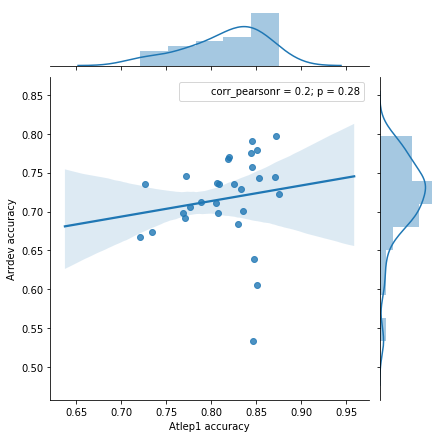

In [10]:
sns.jointplot(a1arrdev_acc, arrdev_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Atlep1 accuracy',
                                                                                        'Arrdev accuracy')
# plt.savefig('../../figures/content-acc-atl1arrdev.pdf')

## is delayed recall accuracy (ability to reinstate context) related to session 2 recall accuracy?

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


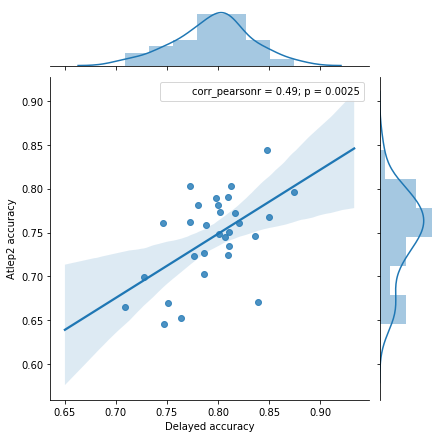

In [11]:
sns.jointplot(dela2_acc, a2_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Delayed accuracy',
                                                                                 'Atlep2 accuracy')
# plt.savefig('../../figures/content-acc-delatl2.pdf')

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


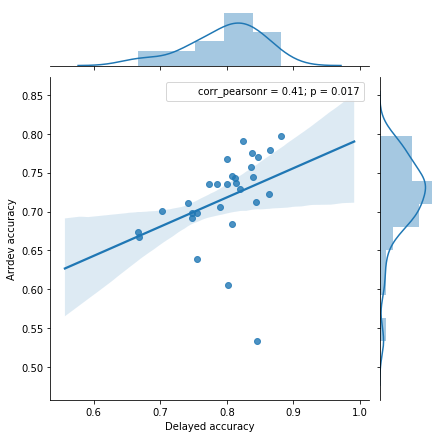

In [12]:
sns.jointplot(delarrdev_acc, arrdev_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Delayed accuracy',
                                                                                 'Arrdev accuracy')
# plt.savefig('../../figures/content-acc-delarrdev.pdf')

## is atlep2 prediction accuracy related to session 2 recall accuracy?

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


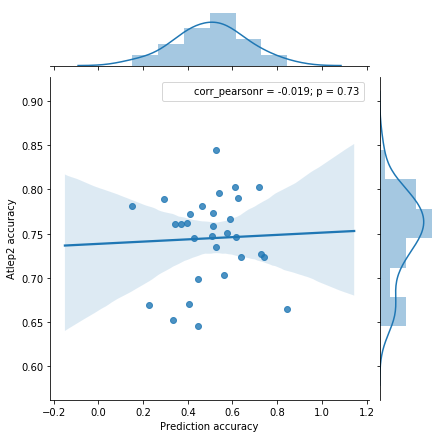

In [13]:
sns.jointplot(preda2_acc, a2_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Prediction accuracy',
                                                                                 'Atlep2 accuracy')
# plt.savefig('../../figures/content-predatl2.pdf')

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


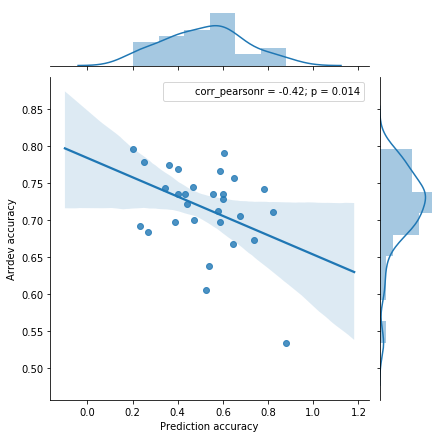

In [14]:
sns.jointplot(predarrdev_acc, arrdev_acc, kind='reg', stat_func=corr_pearsonr).set_axis_labels('Prediction accuracy',
                                                                                 'Arrdev accuracy')
# plt.savefig('../../figures/content-predarrdev.pdf')

## do people who initially remember better also remember better after delay?

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


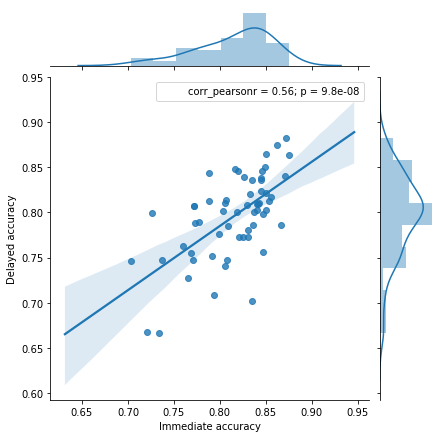

In [136]:
sns.jointplot(a1a2_acc+a1arrdev_acc, dela2_acc+delarrdev_acc, kind='reg', 
              stat_func=corr_pearsonr).set_axis_labels('Immediate accuracy', 'Delayed accuracy')

In [ ]:
# look at whether accuracy for prediction of arrdev content influences memory